# Module 7 — Temperature Scaling and Calibration Audit

**Question.** Does one positive scalar temperature improve LoRA probability quality on rows that were not used to fit that temperature?

**Registered gate.** On each seed's `calibration_assessment` role, scaled 15-bin ECE must be lower than raw ECE and no greater than 0.05; predicted classes must not change.

**Claim boundary.** This notebook reads committed, text-free Module 7 evidence. It never loads BANKING77 messages, model logits or the official test split. The fit and assessment roles are disjoint, but both came from validation pools previously used for Module 6 checkpoint selection. Results are therefore post-selection, post-test exploratory—not independent model evaluation.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def find_repository_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "configs/calibration.yaml").is_file():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the project repository")


ROOT = find_repository_root(Path.cwd().resolve())
REPORT_DIR = ROOT / "reports/calibration"
REGISTRY_PATH = ROOT / "data/manifests/banking77-calibration-index.json"
SEEDS = (17, 42, 73)

registry = json.loads(REGISTRY_PATH.read_text(encoding="utf-8"))
reports = {
    seed: json.loads(
        (REPORT_DIR / f"seed-{seed}-temperature-scaling.json").read_text(encoding="utf-8")
    )
    for seed in SEEDS
}
aggregate = json.loads(
    (REPORT_DIR / "temperature-scaling-aggregate.json").read_text(encoding="utf-8")
)
ROOT.name

'governed-banking-intent-router'

## 1. Verify the evidence boundary before reading results

The assessment is credible only if temperature-fit rows and assessment rows are disjoint, normalized-text groups do not cross roles, no source text is committed, and the official test split was not loaded.

In [2]:
partition_rows = []
for entry in registry["entries"]:
    fit_indices = set(entry["temperature_fit"]["source_indices"])
    assessment_indices = set(entry["calibration_assessment"]["source_indices"])
    assert fit_indices.isdisjoint(assessment_indices)
    assert entry["normalized_text_group_overlap"] == 0
    assert entry["source_index_overlap"] == 0
    partition_rows.append(
        {
            "seed": entry["seed"],
            "temperature_fit": len(fit_indices),
            "calibration_assessment": len(assessment_indices),
            "index_overlap": len(fit_indices & assessment_indices),
            "normalized_group_overlap": entry["normalized_text_group_overlap"],
        }
    )

assert registry["contains_message_text"] is False
assert registry["source_role_history"] == "used_for_module6_checkpoint_selection"
assert registry["model_access_boundary"]["test_split_loaded"] is False
assert aggregate["data_boundary"]["official_test_metrics_computed"] is False
assert aggregate["data_boundary"]["independent_model_evaluation"] is False

partition_frame = pd.DataFrame(partition_rows).set_index("seed")
partition_frame

,temperature_fit,calibration_assessment,index_overlap,normalized_group_overlap
seed,,,,
17,749,750,0,0
42,750,751,0,0
73,749,750,0,0


## 2. Compare raw and scaled assessment metrics

ECE is reported because it is the registered gate, but NLL and multiclass Brier score are included to avoid relying on one bin-dependent statistic. All values below come from `calibration_assessment`, never `temperature_fit`.

In [3]:
metric_names = {
    "expected_calibration_error": "ECE",
    "negative_log_likelihood": "NLL",
    "multiclass_brier_score": "Brier",
    "maximum_calibration_error": "MCE",
    "signed_confidence_gap": "Confidence gap",
}
rows = []
for seed, report in reports.items():
    raw = report["assessment_metrics"]["raw"]
    scaled = report["assessment_metrics"]["calibrated"]
    for key, label in metric_names.items():
        rows.append(
            {
                "seed": seed,
                "metric": label,
                "raw": raw[key],
                "scaled": scaled[key],
                "delta_scaled_minus_raw": scaled[key] - raw[key],
            }
        )
metric_frame = pd.DataFrame(rows)
headline = metric_frame[metric_frame["metric"].isin(["ECE", "NLL", "Brier"])]
headline.pivot(index="seed", columns="metric", values=["raw", "scaled"]).round(4)

raw                  scaled                
metric   Brier     ECE     NLL   Brier     ECE     NLL
seed                                                  
17      0.1354  0.0555  0.3378  0.1317  0.0334  0.3234
42      0.1404  0.0463  0.3216  0.1375  0.0265  0.3090
73      0.1611  0.0391  0.3926  0.1589  0.0242  0.3846

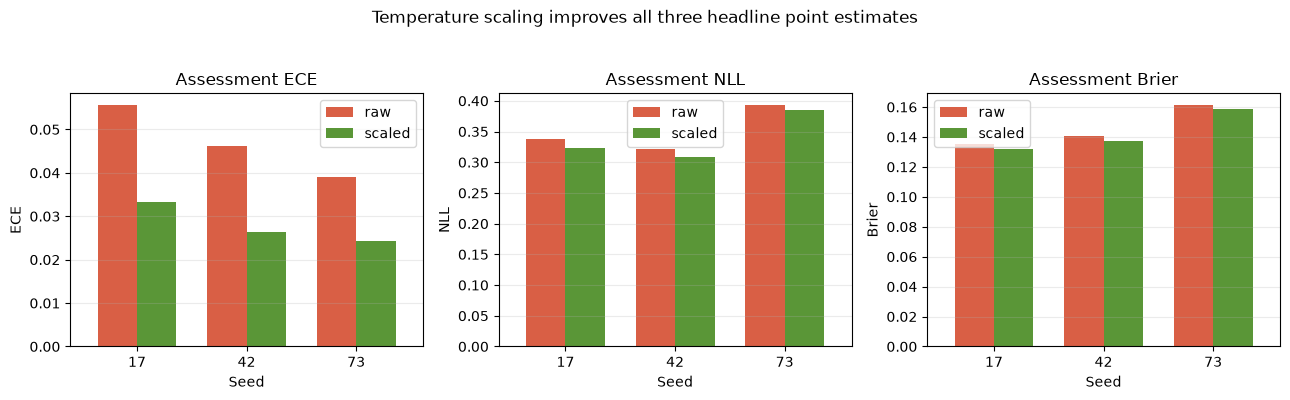

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for axis, metric in zip(axes, ("ECE", "NLL", "Brier"), strict=True):
    subset = headline[headline["metric"] == metric].set_index("seed")
    subset[["raw", "scaled"]].plot(kind="bar", ax=axis, color=["#d95f45", "#5a9637"], width=0.72)
    axis.set_title(f"Assessment {metric}")
    axis.set_xlabel("Seed")
    axis.set_ylabel(metric)
    axis.tick_params(axis="x", rotation=0)
    axis.grid(axis="y", alpha=0.25)
fig.suptitle("Temperature scaling improves all three headline point estimates", y=1.04)
fig.tight_layout()
plt.show()

## 3. Inspect reliability rather than trusting one aggregate number

Seed 42 is shown as the registered central seed. Empty bins are omitted. A perfect reliability curve would follow the diagonal.

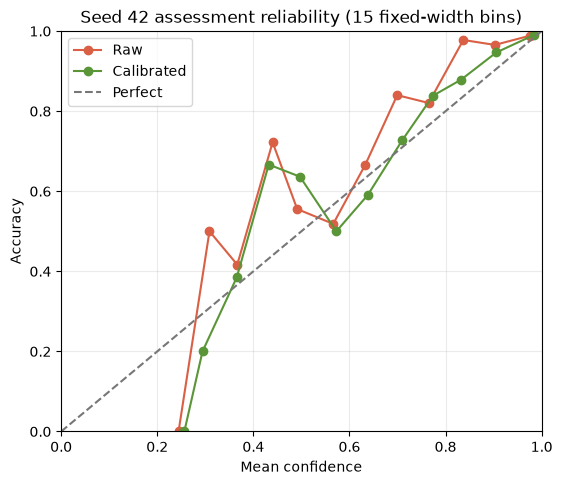

In [5]:
seed_42 = reports[42]["assessment_metrics"]
fig, axis = plt.subplots(figsize=(6.2, 5.2))
for role, color in (("raw", "#d95f45"), ("calibrated", "#5a9637")):
    bins = [row for row in seed_42[role]["reliability_bins"] if row["count"] > 0]
    axis.plot(
        [row["mean_confidence"] for row in bins],
        [row["accuracy"] for row in bins],
        marker="o",
        label=role.title(),
        color=color,
    )
axis.plot([0, 1], [0, 1], linestyle="--", color="#777777", label="Perfect")
axis.set(xlim=(0, 1), ylim=(0, 1), xlabel="Mean confidence", ylabel="Accuracy")
axis.set_title("Seed 42 assessment reliability (15 fixed-width bins)")
axis.grid(alpha=0.25)
axis.legend()
plt.show()

## 4. Test whether improvements survive paired resampling

Each interval uses 2,000 paired bootstrap resamples of the same assessment rows. A calibrated-minus-raw interval below zero supports improvement for an error metric.

In [6]:
interval_rows = []
for seed, report in reports.items():
    point_deltas = report["assessment_metrics"]["calibrated_minus_raw"]
    intervals = report["paired_bootstrap"]["intervals"]
    for key in (
        "expected_calibration_error",
        "negative_log_likelihood",
        "multiclass_brier_score",
        "maximum_calibration_error",
    ):
        interval_rows.append(
            {
                "seed": seed,
                "metric": metric_names[key],
                "point_delta": point_deltas[key],
                "lower_95": intervals[key]["lower"],
                "upper_95": intervals[key]["upper"],
                "interval_supports_improvement": intervals[key]["upper"] < 0,
            }
        )
interval_frame = pd.DataFrame(interval_rows)
interval_frame.round(4)

,seed,metric,point_delta,lower_95,upper_95,interval_supports_improvement
0,17,ECE,-0.0222,-0.0338,-0.0120,True
1,17,NLL,-0.0145,-0.0242,-0.0039,True
2,17,Brier,-0.0038,-0.0063,-0.0010,True
3,17,MCE,0.0163,-0.2104,0.2578,False
4,42,ECE,-0.0198,-0.0281,-0.0064,True
5,42,NLL,-0.0127,-0.0179,-0.0067,True
6,42,Brier,-0.0029,-0.0045,-0.0011,True
7,42,MCE,-0.0258,-0.2339,0.2123,False
8,73,ECE,-0.0149,-0.0258,0.0059,False
9,73,NLL,-0.0080,-0.0145,-0.0007,True


In [7]:
gate_rows = []
for seed, report in reports.items():
    gate_rows.append(
        {
            "seed": seed,
            "temperature": report["temperature_fit"]["temperature"],
            "raw_ece": report["assessment_metrics"]["raw"]["expected_calibration_error"],
            "scaled_ece": report["assessment_metrics"]["calibrated"]["expected_calibration_error"],
            "changed_predictions": report["prediction_invariance"]["changed_class_predictions"],
            "point_gate_passed": report["acceptance_gate"]["all_passed"],
            "ece_interval_below_zero": bool(
                interval_frame.query("seed == @seed and metric == 'ECE'")[
                    "interval_supports_improvement"
                ].iloc[0]
            ),
        }
    )
gate_frame = pd.DataFrame(gate_rows).set_index("seed")
assert gate_frame["point_gate_passed"].all()
assert (gate_frame["changed_predictions"] == 0).all()
gate_frame.round(4)

,temperature,raw_ece,scaled_ece,changed_predictions,point_gate_passed,ece_interval_below_zero
seed,,,,,,
17,0.8285,0.0555,0.0334,0,True,True
42,0.8910,0.0463,0.0265,0,True,True
73,0.8924,0.0391,0.0242,0,True,False


## Conclusion

All three registered point-estimate gates pass: mean assessment ECE falls from 0.0470 to 0.0280, mean NLL from 0.3507 to 0.3390, and mean multiclass Brier score from 0.1456 to 0.1427. Positive temperatures below one sharpen probabilities and change zero predicted classes.

The counter-evidence matters. Seed 73's bootstrap ECE interval crosses zero, seed 17's point MCE worsens, and MCE intervals are wide. The defensible result is that temperature scaling improved several probability-quality measures on these disjoint assessment roles—not that the classifier is calibrated for production.

**Next module:** evaluate uncertainty and possible-OOD signals with separately registered threshold-development and assessment data. Confidence must not be treated as an OOD guarantee.